# Correlation Analysis with the Iris Dataset

**A beginner-friendly guide to understanding relationships between variables**

---

## What is Correlation?

Imagine you notice that taller people tend to weigh more. That's a correlation — when one thing goes up, the other tends to go up too.

More formally: **correlation measures the strength and direction of a linear relationship between two numeric variables.**

The correlation coefficient `r` always lives between **-1 and +1**:

| r value | Meaning |
|---|---|
| +1.0 | Perfect positive — one goes up, other always goes up |
| +0.7 to +0.9 | Strong positive |
| +0.3 to +0.7 | Moderate positive |
| -0.3 to +0.3 | Weak or no relationship |
| -0.3 to -0.7 | Moderate negative |
| -0.7 to -0.9 | Strong negative |
| -1.0 | Perfect negative — one goes up, other always goes down |

## What Dataset Are We Using?

The **Iris dataset** contains measurements of 150 iris flowers across 3 species:  
- **Setosa**, **Versicolor**, and **Virginica**

Each flower has 4 numeric measurements:
- `sepal_length` — length of the sepal (outer petal-like leaf), in cm
- `sepal_width` — width of the sepal, in cm
- `petal_length` — length of the petal, in cm
- `petal_width` — width of the petal, in cm

**Question we'll explore:** Do flowers with longer petals also tend to have wider petals? Do larger sepals mean larger petals?

---

## Tutorial Structure

1. Setup & Load Data  
2. Explore the Data (EDA)  
3. Visualize Correlation Concepts  
4. Pearson Correlation (the classic method)  
5. Check Assumptions  
6. Spearman Correlation (the robust alternative)  
7. Partial Correlation (controlling for species)  
8. Confidence Intervals with Fisher's Z  
9. Summary & Key Takeaways  

---
## Section 1 — Setup & Load Data

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats
from scipy.stats import pearsonr, spearmanr, shapiro
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ── Load the Iris dataset from sklearn ───────────────────────────────────────
iris_raw = load_iris()

# Convert to a pandas DataFrame so it's easy to work with
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)

# Rename columns to something cleaner
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Add the species column (0=setosa, 1=versicolor, 2=virginica)
df['species'] = iris_raw.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Quick preview
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nSpecies counts:")
print(df['species'].value_counts())

Dataset shape: (150, 5)

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Species counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---
## Section 2 — Exploratory Data Analysis (EDA)

Before running any correlation test, it's important to **understand your data first**. We'll check:

- Basic statistics (mean, min, max)
- Are there missing values?
- What do the distributions look like?
- Are there outliers?
- Are the variables normally distributed? *(This matters for choosing the right correlation method.)*

In [3]:
# ── Basic descriptive statistics ─────────────────────────────────────────────
numeric_vars = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
print(df[numeric_vars].describe().round(2))

print("\nMissing values per column:")
print(df.isnull().sum())
print("\nGreat — no missing values in this dataset!")

DESCRIPTIVE STATISTICS
       sepal_length  sepal_width  petal_length  petal_width
count        150.00       150.00        150.00       150.00
mean           5.84         3.06          3.76         1.20
std            0.83         0.44          1.77         0.76
min            4.30         2.00          1.00         0.10
25%            5.10         2.80          1.60         0.30
50%            5.80         3.00          4.35         1.30
75%            6.40         3.30          5.10         1.80
max            7.90         4.40          6.90         2.50

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Great — no missing values in this dataset!


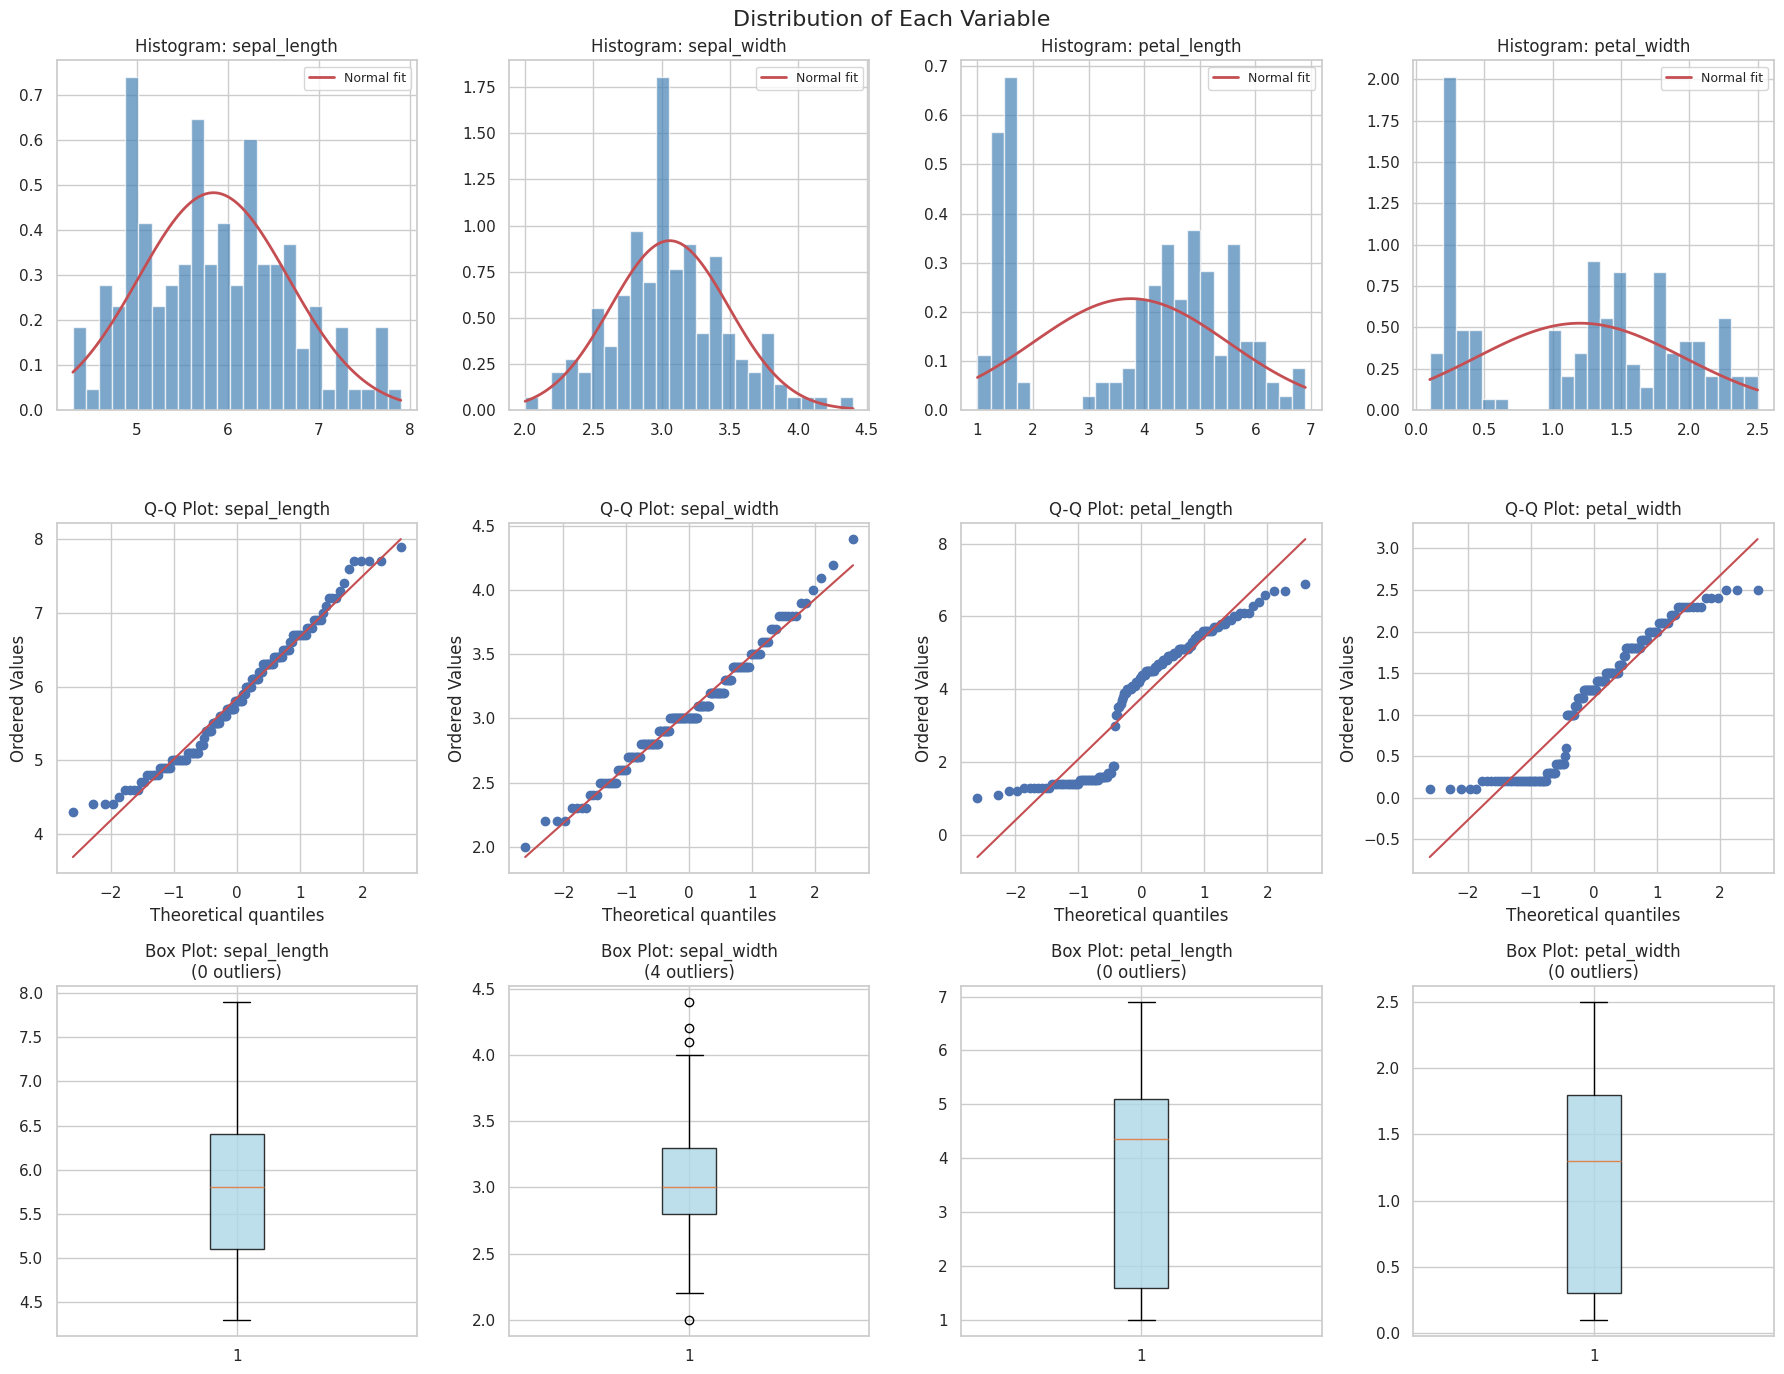


Normality Test (Shapiro-Wilk):
--------------------------------------------------
  Rule: p > 0.05 → data is likely normal

  sepal_length      : W=0.9761, p=0.0102  →  Non-normal ✗
  sepal_width       : W=0.9849, p=0.1012  →  Normal ✓
  petal_length      : W=0.8763, p=0.0000  →  Non-normal ✗
  petal_width       : W=0.9018, p=0.0000  →  Non-normal ✗


In [4]:
# ── Distribution plots: histogram + Q-Q plot + boxplot ───────────────────────
# Q-Q plot: if the dots follow a straight line, the data is normally distributed.
# Shapiro-Wilk test: p > 0.05 means we can assume normality.

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
fig.suptitle('Distribution of Each Variable', fontsize=16)

for i, var in enumerate(numeric_vars):
    col_data = df[var]

    # Row 0: Histogram
    axes[0, i].hist(col_data, bins=25, density=True, alpha=0.7,
                    color='steelblue', edgecolor='white')
    mu, sigma = stats.norm.fit(col_data)
    x_line = np.linspace(col_data.min(), col_data.max(), 100)
    axes[0, i].plot(x_line, stats.norm.pdf(x_line, mu, sigma), 'r-',
                    linewidth=2, label='Normal fit')
    axes[0, i].set_title(f'Histogram: {var}')
    axes[0, i].legend(fontsize=9)

    # Row 1: Q-Q plot
    stats.probplot(col_data, dist='norm', plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q Plot: {var}')

    # Row 2: Box plot
    axes[2, i].boxplot(col_data, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.8))
    # Count outliers using IQR method
    Q1, Q3 = col_data.quantile(0.25), col_data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = col_data[(col_data < Q1 - 1.5*IQR) | (col_data > Q3 + 1.5*IQR)]
    axes[2, i].set_title(f'Box Plot: {var}\n({len(outliers)} outliers)')

plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
print("\nNormality Test (Shapiro-Wilk):")
print("-" * 50)
print("  Rule: p > 0.05 → data is likely normal\n")
for var in numeric_vars:
    stat, p = shapiro(df[var])
    label = 'Normal ✓' if p > 0.05 else 'Non-normal ✗'
    print(f"  {var:<18}: W={stat:.4f}, p={p:.4f}  →  {label}")

Mean values per species:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa              5.01         3.43          1.46         0.25
versicolor          5.94         2.77          4.26         1.33
virginica           6.59         2.97          5.55         2.03


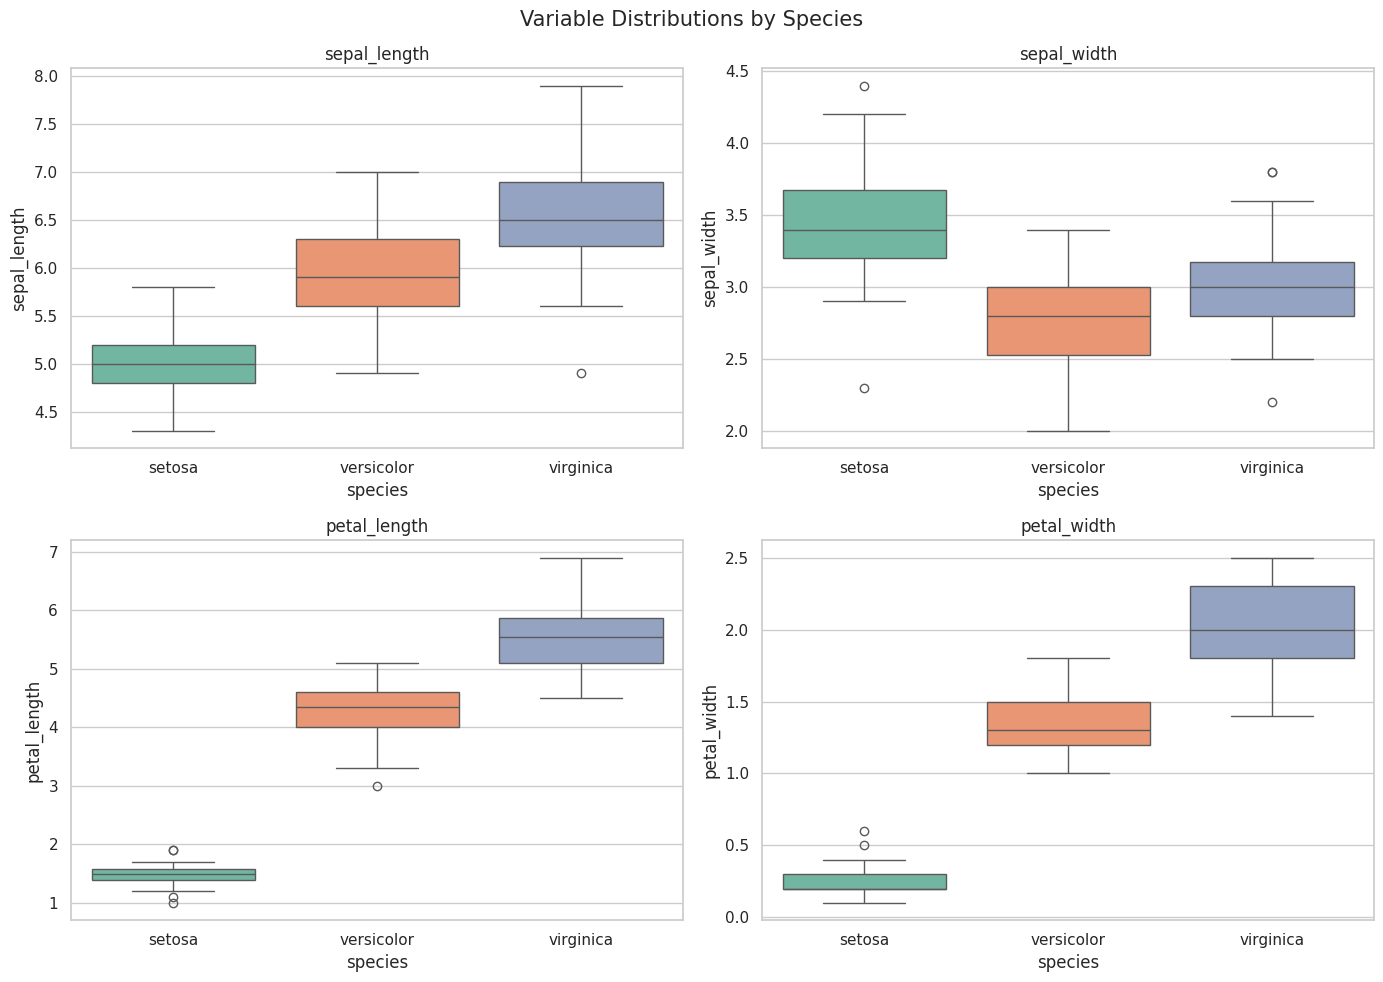


⚠  Notice: The 3 species have very different petal sizes.
   This means petal correlations across all species may reflect
   species differences, not within-species biology.
   → We'll control for this later using partial correlation.


In [5]:
# ── Species-level differences ─────────────────────────────────────────────────
# Why does this matter? If each species has very different measurements,
# then a correlation across ALL species might be driven by species differences,
# not an actual biological relationship within a species.
# (We'll address this with Partial Correlation in Section 7.)

print("Mean values per species:")
print(df.groupby('species')[numeric_vars].mean().round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Variable Distributions by Species', fontsize=15)

for i, var in enumerate(numeric_vars):
    row, col = divmod(i, 2)
    sns.boxplot(data=df, x='species', y=var, ax=axes[row, col],
                palette='Set2')
    axes[row, col].set_title(var)

plt.tight_layout()
plt.show()

print("\n⚠  Notice: The 3 species have very different petal sizes.")
print("   This means petal correlations across all species may reflect")
print("   species differences, not within-species biology.")
print("   → We'll control for this later using partial correlation.")

---
## Section 3 — Visualizing Correlation Concepts

Before calculating any numbers, let's build an intuition for what different correlation strengths *look like* in scatter plots.

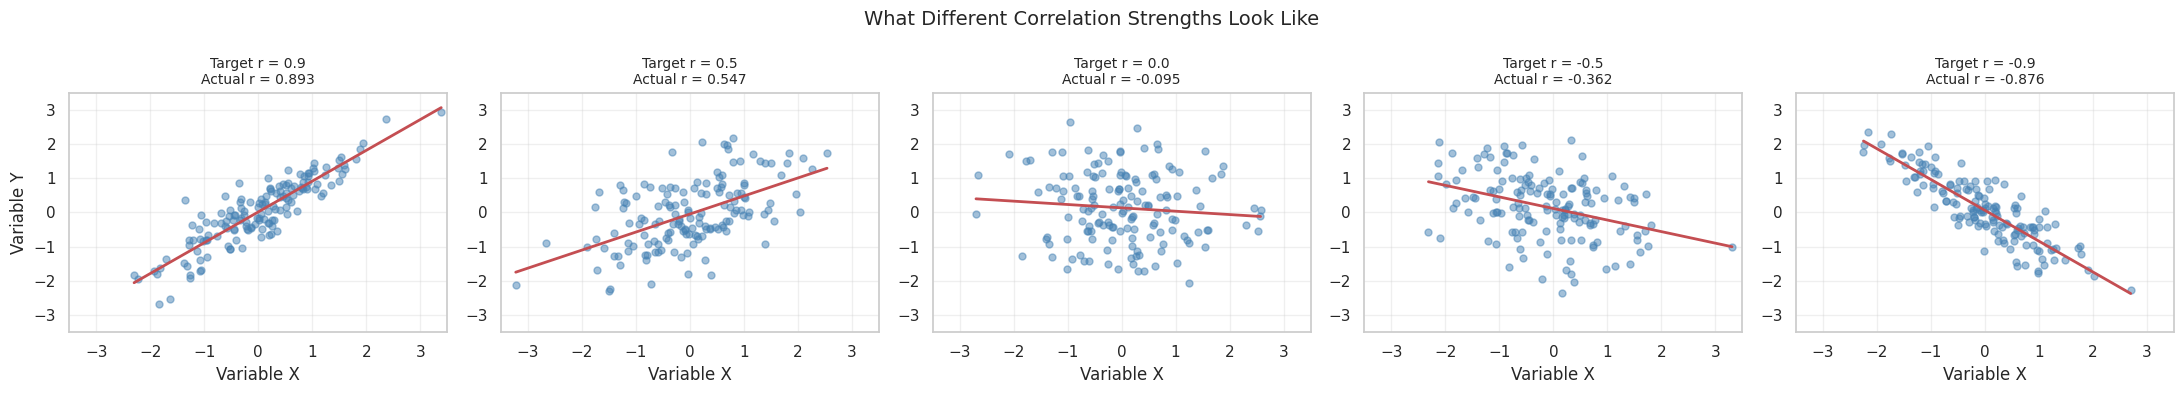

Key observations:
  r = +0.9  → tight upward-sloping cloud (strong positive)
  r = +0.5  → loose upward trend (moderate positive)
  r =  0.0  → no clear direction (no relationship)
  r = -0.5  → loose downward trend (moderate negative)
  r = -0.9  → tight downward cloud (strong negative)


In [6]:
# ── Simulated examples of correlation strengths ───────────────────────────────
np.random.seed(42)
n = 150
target_rs = [0.9, 0.5, 0.0, -0.5, -0.9]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('What Different Correlation Strengths Look Like', fontsize=14)

for ax, r in zip(axes, target_rs):
    cov = [[1, r], [r, 1]]
    data = np.random.multivariate_normal([0, 0], cov, n)
    x, y = data[:, 0], data[:, 1]
    actual_r, _ = pearsonr(x, y)

    ax.scatter(x, y, alpha=0.5, s=25, color='steelblue')
    # Regression line
    m, b, *_ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, m*xl + b, 'r-', linewidth=2)

    ax.set_title(f'Target r = {r}\nActual r = {actual_r:.3f}', fontsize=10)
    ax.set_xlabel('Variable X')
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Variable Y')
plt.tight_layout()
plt.show()

print("Key observations:")
print("  r = +0.9  → tight upward-sloping cloud (strong positive)")
print("  r = +0.5  → loose upward trend (moderate positive)")
print("  r =  0.0  → no clear direction (no relationship)")
print("  r = -0.5  → loose downward trend (moderate negative)")
print("  r = -0.9  → tight downward cloud (strong negative)")

---
## Section 4 — Pearson Correlation (the Classic Method)

**Pearson's r** is the most common correlation method. It measures the *linear* relationship between two variables.

**Formula:**
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$$

In plain English: it asks, "when X is above its average, is Y also above its average?"

**When to use Pearson:** when both variables are roughly normally distributed and their relationship is linear (straight-line).

In [7]:
# ── Pairwise Pearson correlations ─────────────────────────────────────────────
print("=" * 65)
print("PEARSON CORRELATION — ALL PAIRS")
print("=" * 65)
print("  r = correlation coefficient  |  p = p-value  |  n = sample size")
print("  p < 0.05 → correlation is statistically significant\n")

from itertools import combinations

results = []
for v1, v2 in combinations(numeric_vars, 2):
    r, p = pearsonr(df[v1], df[v2])
    strength = 'Strong' if abs(r) >= 0.7 else ('Moderate' if abs(r) >= 0.3 else 'Weak')
    direction = 'positive' if r > 0 else 'negative'
    sig = 'Significant ✓' if p < 0.05 else 'Not significant'
    results.append({'var1': v1, 'var2': v2, 'r': r, 'p': p, 'strength': strength,
                    'direction': direction, 'significance': sig})
    print(f"  {v1}  ↔  {v2}")
    print(f"    r = {r:+.3f},  p = {p:.4f},  n = {len(df)}")
    print(f"    → {strength} {direction} correlation  ({sig})")
    print()

PEARSON CORRELATION — ALL PAIRS
  r = correlation coefficient  |  p = p-value  |  n = sample size
  p < 0.05 → correlation is statistically significant

  sepal_length  ↔  sepal_width
    r = -0.118,  p = 0.1519,  n = 150
    → Weak negative correlation  (Not significant)

  sepal_length  ↔  petal_length
    r = +0.872,  p = 0.0000,  n = 150
    → Strong positive correlation  (Significant ✓)

  sepal_length  ↔  petal_width
    r = +0.818,  p = 0.0000,  n = 150
    → Strong positive correlation  (Significant ✓)

  sepal_width  ↔  petal_length
    r = -0.428,  p = 0.0000,  n = 150
    → Moderate negative correlation  (Significant ✓)

  sepal_width  ↔  petal_width
    r = -0.366,  p = 0.0000,  n = 150
    → Moderate negative correlation  (Significant ✓)

  petal_length  ↔  petal_width
    r = +0.963,  p = 0.0000,  n = 150
    → Strong positive correlation  (Significant ✓)



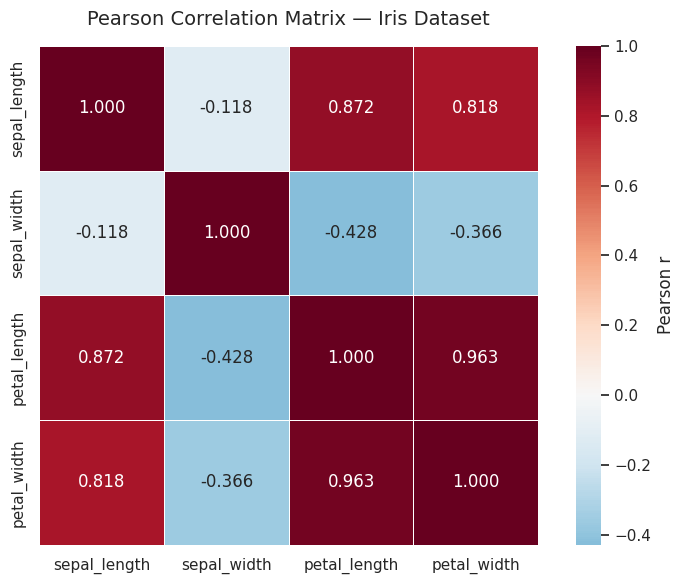

Reading the heatmap:
  - Each cell shows the correlation between the row variable and the column variable.
  - The diagonal is always 1.0 (any variable perfectly correlates with itself).
  - petal_length and petal_width: r ≈ 0.96 — extremely strong positive!


In [8]:
# ── Correlation matrix heatmap ────────────────────────────────────────────────
# A heatmap lets you see ALL correlations at once.
# Blue = positive, Red = negative, Darker = stronger.

corr_matrix = df[numeric_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Pearson Correlation Matrix — Iris Dataset', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("Reading the heatmap:")
print("  - Each cell shows the correlation between the row variable and the column variable.")
print("  - The diagonal is always 1.0 (any variable perfectly correlates with itself).")
print("  - petal_length and petal_width: r ≈ 0.96 — extremely strong positive!")

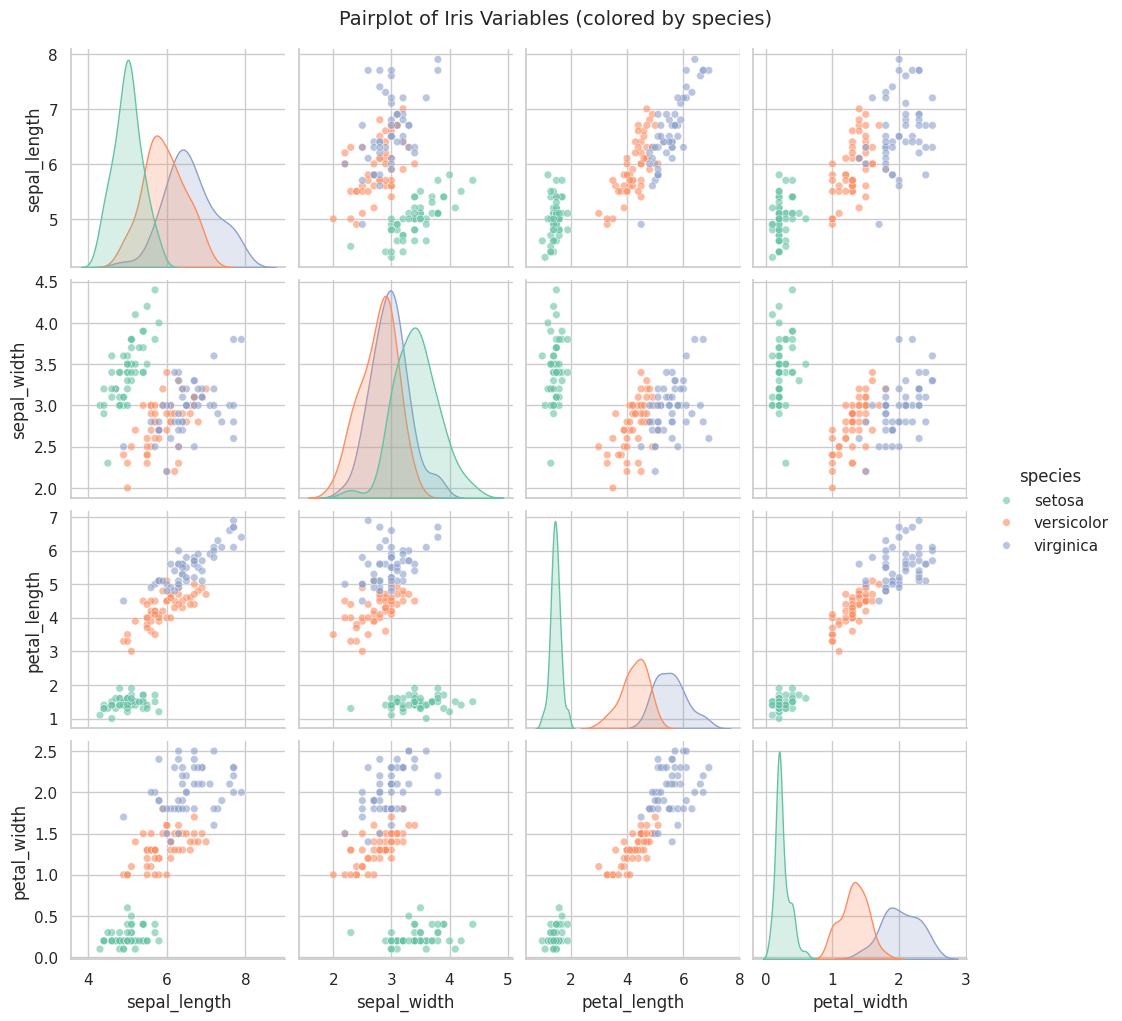

What to notice:
  - petal_length vs petal_width: tight linear cloud → high correlation
  - sepal_width vs others: looser cloud → weaker correlation
  - Colors show that species clusters occupy different regions


In [9]:
# ── Pair plot: scatter plots for all variable combinations ────────────────────
# Each cell in the grid is a scatter plot of two variables.
# Different colors = different species.

pair_plot = sns.pairplot(df, hue='species', vars=numeric_vars,
                         diag_kind='kde', palette='Set2',
                         plot_kws={'alpha': 0.6, 's': 30})
pair_plot.figure.suptitle('Pairplot of Iris Variables (colored by species)',
                           y=1.02, fontsize=14)
plt.show()

print("What to notice:")
print("  - petal_length vs petal_width: tight linear cloud → high correlation")
print("  - sepal_width vs others: looser cloud → weaker correlation")
print("  - Colors show that species clusters occupy different regions")

---
## Section 5 — Checking Pearson's Assumptions

Pearson correlation is only reliable when certain conditions are met. If they're violated, the correlation coefficient may be misleading.

**The 4 main assumptions:**

| Assumption | What it means | How we test it |
|---|---|---|
| **Linearity** | Relationship should be a straight line, not a curve | Compare linear vs. quadratic R² |
| **Normality** | Both variables should be roughly bell-shaped | Shapiro-Wilk test |
| **Homoscedasticity** | Spread of data should be consistent across values | Residuals vs. fitted values plot |
| **No extreme outliers** | Outliers can heavily distort r | Z-score method (|z| > 3) |


  ASSUMPTION CHECK: petal_length  ↔  petal_width
  n = 150 observations

1. LINEARITY
   Linear R² = 0.9271,  Quadratic R² = 0.9272
   R² improvement = 0.0001  (threshold: < 0.05)
   → PASS ✓ — relationship is sufficiently linear

2. NORMALITY (Shapiro-Wilk, p > 0.05 = normal)
   petal_length: p = 0.0000  → Non-normal ✗
   petal_width: p = 0.0000  → Non-normal ✗

3. HOMOSCEDASTICITY (equal spread)
   Correlation |residuals| vs fitted: r = 0.5161, p = 0.0000
   → VIOLATED ✗ — unequal variance

4. OUTLIERS (z-score > 3)
   petal_length: 0 outliers,  petal_width: 0 outliers
   → PASS ✓ — fewer than 5% outliers

────────────────────────────────────────
  Assumptions passed: 2/4
  Recommendation: Use both Pearson and Spearman; compare results.


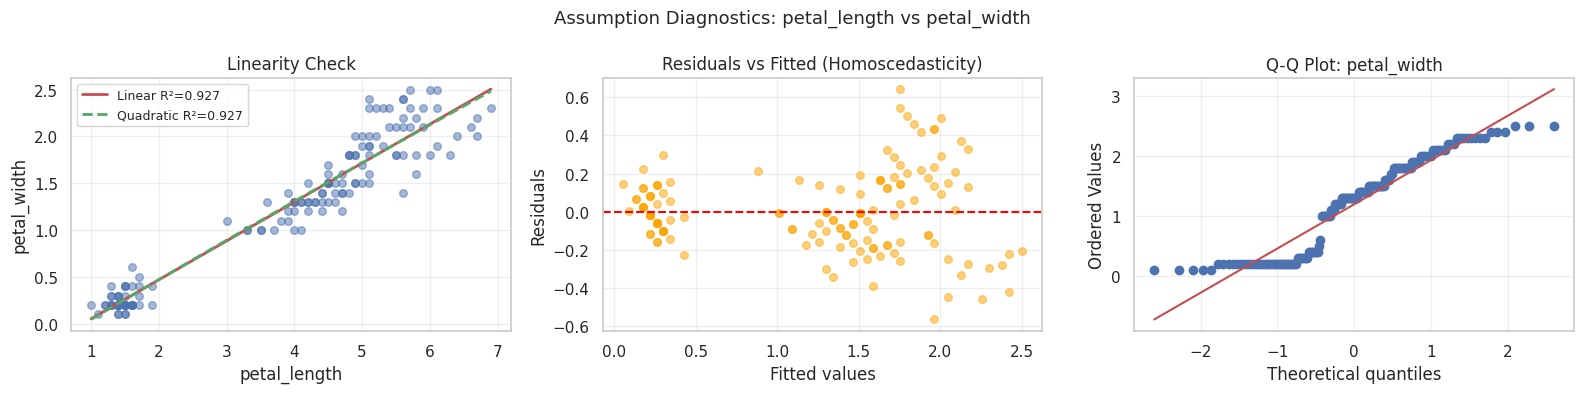

np.int64(2)

In [10]:
# ── Assumption checker function ───────────────────────────────────────────────
def check_assumptions(df, var1, var2):
    """
    Check Pearson correlation assumptions for a pair of variables.
    Returns a summary of which assumptions pass or fail.
    """
    x, y = df[var1].values, df[var2].values
    n = len(x)

    print(f"\n{'='*60}")
    print(f"  ASSUMPTION CHECK: {var1}  ↔  {var2}")
    print(f"  n = {n} observations")
    print(f"{'='*60}")

    # --- 1. Linearity ---
    linear_coef = np.polyfit(x, y, 1)
    linear_pred = np.polyval(linear_coef, x)
    linear_r2 = 1 - np.sum((y - linear_pred)**2) / np.sum((y - y.mean())**2)

    quad_coef = np.polyfit(x, y, 2)
    quad_pred = np.polyval(quad_coef, x)
    quad_r2 = 1 - np.sum((y - quad_pred)**2) / np.sum((y - y.mean())**2)

    r2_gain = quad_r2 - linear_r2
    linear_ok = r2_gain < 0.05
    print(f"\n1. LINEARITY")
    print(f"   Linear R² = {linear_r2:.4f},  Quadratic R² = {quad_r2:.4f}")
    print(f"   R² improvement = {r2_gain:.4f}  (threshold: < 0.05)")
    print(f"   → {'PASS ✓ — relationship is sufficiently linear' if linear_ok else 'QUESTIONABLE ⚠ — possible curve'}")

    # --- 2. Normality ---
    _, p_x = shapiro(x)
    _, p_y = shapiro(y)
    norm_ok = (p_x > 0.05) and (p_y > 0.05)
    print(f"\n2. NORMALITY (Shapiro-Wilk, p > 0.05 = normal)")
    print(f"   {var1}: p = {p_x:.4f}  → {'Normal ✓' if p_x > 0.05 else 'Non-normal ✗'}")
    print(f"   {var2}: p = {p_y:.4f}  → {'Normal ✓' if p_y > 0.05 else 'Non-normal ✗'}")

    # --- 3. Homoscedasticity ---
    residuals = y - linear_pred
    hetero_r, hetero_p = pearsonr(linear_pred, np.abs(residuals))
    homo_ok = hetero_p > 0.05
    print(f"\n3. HOMOSCEDASTICITY (equal spread)")
    print(f"   Correlation |residuals| vs fitted: r = {hetero_r:.4f}, p = {hetero_p:.4f}")
    print(f"   → {'PASS ✓ — constant variance' if homo_ok else 'VIOLATED ✗ — unequal variance'}")

    # --- 4. Outliers ---
    z_x = np.abs(stats.zscore(x))
    z_y = np.abs(stats.zscore(y))
    out_x = np.sum(z_x > 3)
    out_y = np.sum(z_y > 3)
    total_out = max(out_x, out_y)
    out_ok = total_out < 0.05 * n
    print(f"\n4. OUTLIERS (z-score > 3)")
    print(f"   {var1}: {out_x} outliers,  {var2}: {out_y} outliers")
    print(f"   → {'PASS ✓ — fewer than 5% outliers' if out_ok else 'ATTENTION ⚠ — many outliers'}")

    # --- Recommendation ---
    passed = sum([linear_ok, norm_ok, homo_ok, out_ok])
    print(f"\n{'─'*40}")
    print(f"  Assumptions passed: {passed}/4")
    if passed >= 3:
        rec = "Pearson correlation is appropriate."
    elif passed >= 2:
        rec = "Use both Pearson and Spearman; compare results."
    else:
        rec = "Use Spearman correlation (more robust)."
    print(f"  Recommendation: {rec}")

    # --- Diagnostic Plots ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Assumption Diagnostics: {var1} vs {var2}', fontsize=13)

    x_line = np.linspace(x.min(), x.max(), 100)
    axes[0].scatter(x, y, alpha=0.5, s=30)
    axes[0].plot(x_line, np.polyval(linear_coef, x_line), 'r-', lw=2,
                 label=f'Linear R²={linear_r2:.3f}')
    axes[0].plot(x_line, np.polyval(quad_coef, x_line), 'g--', lw=2,
                 label=f'Quadratic R²={quad_r2:.3f}')
    axes[0].set_title('Linearity Check'); axes[0].legend(fontsize=9)
    axes[0].set_xlabel(var1); axes[0].set_ylabel(var2)

    axes[1].scatter(linear_pred, residuals, alpha=0.5, s=30, color='orange')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title('Residuals vs Fitted (Homoscedasticity)')
    axes[1].set_xlabel('Fitted values'); axes[1].set_ylabel('Residuals')

    stats.probplot(y, dist='norm', plot=axes[2])
    axes[2].set_title(f'Q-Q Plot: {var2}')

    for ax in axes: ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return passed


# Check the most interesting pair
check_assumptions(df, 'petal_length', 'petal_width')


  ASSUMPTION CHECK: sepal_length  ↔  sepal_width
  n = 150 observations

1. LINEARITY
   Linear R² = 0.0138,  Quadratic R² = 0.0378
   R² improvement = 0.0240  (threshold: < 0.05)
   → PASS ✓ — relationship is sufficiently linear

2. NORMALITY (Shapiro-Wilk, p > 0.05 = normal)
   sepal_length: p = 0.0102  → Non-normal ✗
   sepal_width: p = 0.1012  → Normal ✓

3. HOMOSCEDASTICITY (equal spread)
   Correlation |residuals| vs fitted: r = 0.1793, p = 0.0281
   → VIOLATED ✗ — unequal variance

4. OUTLIERS (z-score > 3)
   sepal_length: 0 outliers,  sepal_width: 1 outliers
   → PASS ✓ — fewer than 5% outliers

────────────────────────────────────────
  Assumptions passed: 2/4
  Recommendation: Use both Pearson and Spearman; compare results.


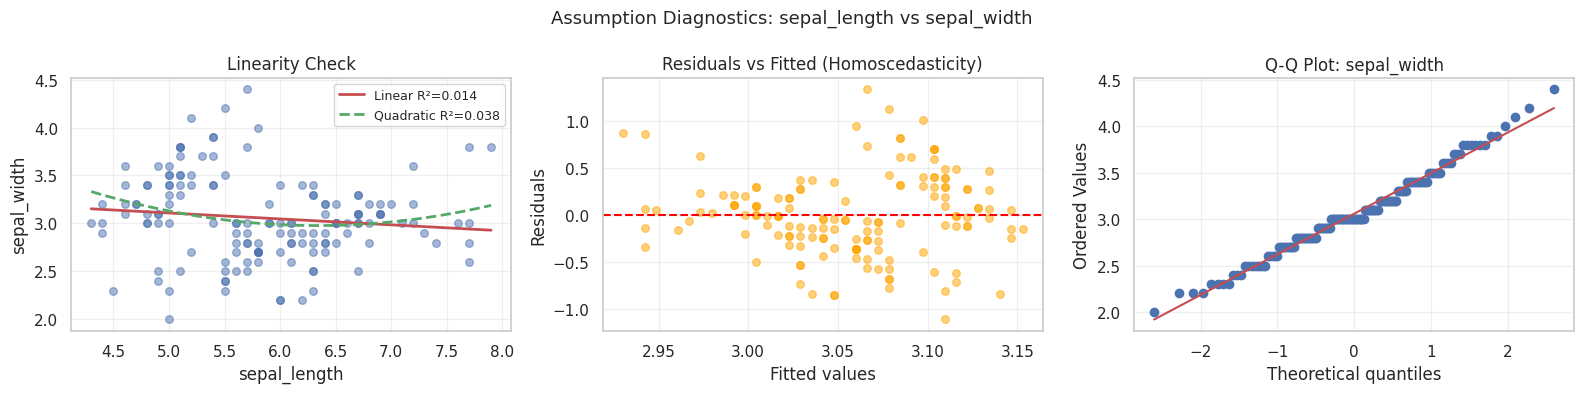

np.int64(2)

In [11]:
# Check another pair
check_assumptions(df, 'sepal_length', 'sepal_width')

---
## Section 6 — Spearman Correlation (the Robust Alternative)

**Spearman's ρ (rho)** is a non-parametric version of Pearson. Instead of using the actual values, it ranks them first and then computes the Pearson correlation on those ranks.

**Why use Spearman?**
- Data is not normally distributed
- There are outliers
- The relationship might be monotonic but not strictly linear  
  *(monotonic = consistently increasing or decreasing, but not necessarily in a straight line)*

**Interpretation:** Same scale as Pearson (-1 to +1). A high ρ means as X increases, Y tends to increase too — even if not in a perfectly straight-line way.

In [12]:
# ── Spearman vs Pearson side-by-side ──────────────────────────────────────────
print("=" * 70)
print("SPEARMAN vs PEARSON CORRELATION")
print("=" * 70)
print("  When both methods agree (small difference), the relationship is linear")
print("  and Pearson is fine. Large differences suggest non-linearity or outliers.\n")

spearman_results = []
for v1, v2 in combinations(numeric_vars, 2):
    r_p, _ = pearsonr(df[v1], df[v2])
    r_s, p_s = spearmanr(df[v1], df[v2])
    diff = abs(r_s - r_p)
    agreement = 'High agreement ✓' if diff < 0.1 else ('Moderate ⚠' if diff < 0.2 else 'Poor ✗')
    spearman_results.append((v1, v2, r_p, r_s, diff, agreement))

    print(f"  {v1} ↔ {v2}")
    print(f"    Pearson r  = {r_p:+.3f}")
    print(f"    Spearman ρ = {r_s:+.3f}   (p = {p_s:.4f})")
    print(f"    Difference = {diff:.3f}   → {agreement}")
    print()

SPEARMAN vs PEARSON CORRELATION
  When both methods agree (small difference), the relationship is linear
  and Pearson is fine. Large differences suggest non-linearity or outliers.

  sepal_length ↔ sepal_width
    Pearson r  = -0.118
    Spearman ρ = -0.167   (p = 0.0414)
    Difference = 0.049   → High agreement ✓

  sepal_length ↔ petal_length
    Pearson r  = +0.872
    Spearman ρ = +0.882   (p = 0.0000)
    Difference = 0.010   → High agreement ✓

  sepal_length ↔ petal_width
    Pearson r  = +0.818
    Spearman ρ = +0.834   (p = 0.0000)
    Difference = 0.016   → High agreement ✓

  sepal_width ↔ petal_length
    Pearson r  = -0.428
    Spearman ρ = -0.310   (p = 0.0001)
    Difference = 0.119   → Moderate ⚠

  sepal_width ↔ petal_width
    Pearson r  = -0.366
    Spearman ρ = -0.289   (p = 0.0003)
    Difference = 0.077   → High agreement ✓

  petal_length ↔ petal_width
    Pearson r  = +0.963
    Spearman ρ = +0.938   (p = 0.0000)
    Difference = 0.025   → High agreement ✓



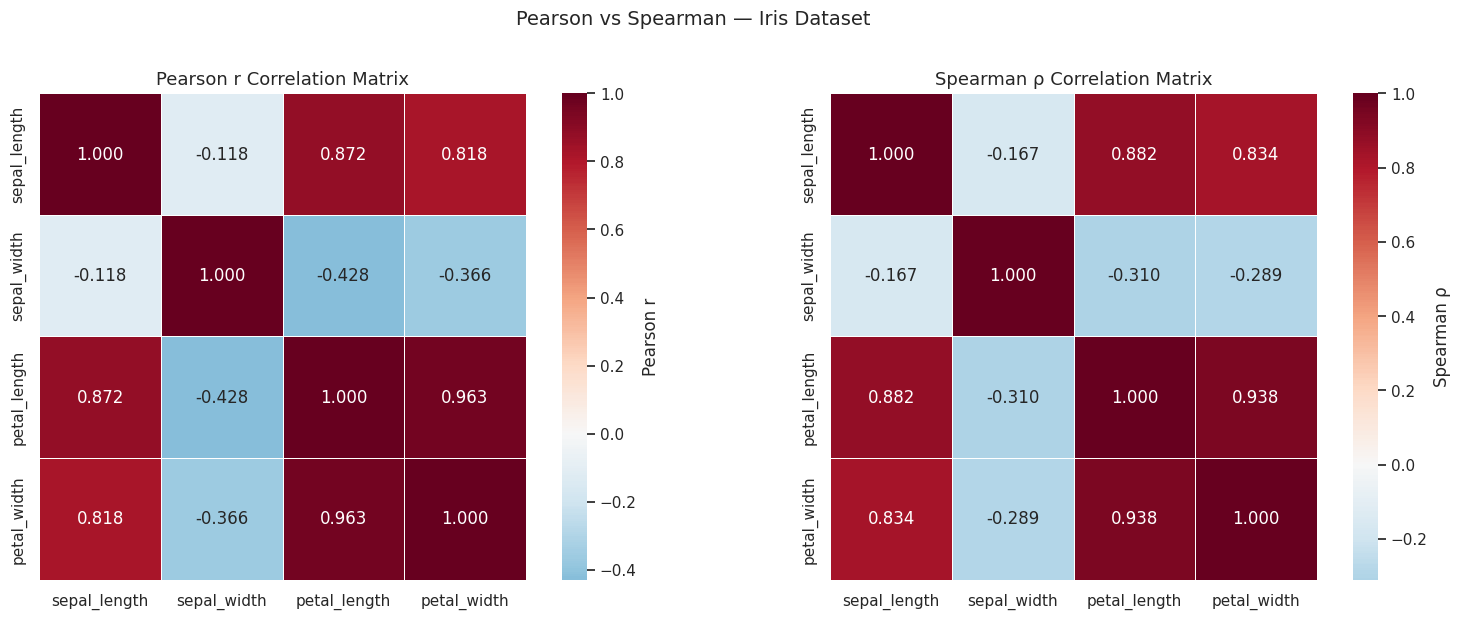

Key observation: Pearson and Spearman agree closely for this dataset,
suggesting the relationships are largely linear.


In [13]:
# ── Side-by-side heatmaps ─────────────────────────────────────────────────────
pearson_mat = df[numeric_vars].corr(method='pearson')
spearman_mat = df[numeric_vars].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mat, title in zip(axes,
                          [pearson_mat, spearman_mat],
                          ['Pearson r', 'Spearman ρ']):
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax,
                cbar_kws={'label': title})
    ax.set_title(f'{title} Correlation Matrix', fontsize=13)

plt.suptitle('Pearson vs Spearman — Iris Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Key observation: Pearson and Spearman agree closely for this dataset,")
print("suggesting the relationships are largely linear.")

---
## Section 7 — Partial Correlation (Controlling for Species)

### The Problem

When we computed the correlation between `petal_length` and `petal_width` across all flowers, we got r ≈ 0.96. But wait — **is this because petals that are long tend to also be wide, or is it just because Virginica flowers (larger species) have both long AND wide petals?**

This is the **confounding variable problem**. Species is a confounding variable — it influences both petal measurements.

### The Solution: Partial Correlation

Partial correlation removes the effect of a third variable (species) and tells us the *direct* relationship between two variables.

**How it works (residuals method):**
1. Regress `petal_length` on species → get residuals (the part of petal_length NOT explained by species)
2. Regress `petal_width` on species → get residuals (the part of petal_width NOT explained by species)
3. Correlate those two residuals → that's the partial correlation

**Formula (for one control variable Z):**
$$r_{XY \cdot Z} = \frac{r_{XY} - r_{XZ} \cdot r_{YZ}}{\sqrt{(1 - r_{XZ}^2)(1 - r_{YZ}^2)}}$$

In [14]:
# ── Encode species as numbers for regression ──────────────────────────────────
# We can't directly regress on text ("setosa", etc.), so encode as 0/1/2
df['species_code'] = df['species'].map({'setosa': 0, 'versicolor': 1, 'virginica': 2})

def partial_correlation(df, var1, var2, control_var):
    """
    Compute partial correlation between var1 and var2,
    controlling for control_var.

    Method: residuals approach
    1. Regress var1 on control_var → residuals1
    2. Regress var2 on control_var → residuals2
    3. Pearson correlation between residuals1 and residuals2
    """
    from sklearn.linear_model import LinearRegression

    Z = df[[control_var]].values

    # Regress var1 on control variable
    reg1 = LinearRegression().fit(Z, df[var1])
    res1 = df[var1] - reg1.predict(Z)  # residuals

    # Regress var2 on control variable
    reg2 = LinearRegression().fit(Z, df[var2])
    res2 = df[var2] - reg2.predict(Z)  # residuals

    # Partial correlation = Pearson on residuals
    r_partial, p_partial = pearsonr(res1, res2)
    return r_partial, p_partial, res1, res2


# ── Compare simple vs partial correlation ────────────────────────────────────
print("=" * 65)
print("PARTIAL CORRELATION — Controlling for Species")
print("=" * 65)
print("  Simple correlation: uses all flowers together")
print("  Partial correlation: removes species effect first\n")

for v1, v2 in combinations(numeric_vars, 2):
    r_simple, _ = pearsonr(df[v1], df[v2])
    r_partial, p_partial, _, _ = partial_correlation(df, v1, v2, 'species_code')
    change = r_partial - r_simple

    print(f"  {v1} ↔ {v2}")
    print(f"    Simple Pearson r      = {r_simple:+.3f}")
    print(f"    Partial r (|species)  = {r_partial:+.3f}  (p = {p_partial:.4f})")
    print(f"    Change                = {change:+.3f}")
    print()

PARTIAL CORRELATION — Controlling for Species
  Simple correlation: uses all flowers together
  Partial correlation: removes species effect first

  sepal_length ↔ sepal_width
    Simple Pearson r      = -0.118
    Partial r (|species)  = +0.384  (p = 0.0000)
    Change                = +0.502

  sepal_length ↔ petal_length
    Simple Pearson r      = +0.872
    Partial r (|species)  = +0.658  (p = 0.0000)
    Change                = -0.214

  sepal_length ↔ petal_width
    Simple Pearson r      = +0.818
    Partial r (|species)  = +0.382  (p = 0.0000)
    Change                = -0.436

  sepal_width ↔ petal_length
    Simple Pearson r      = -0.428
    Partial r (|species)  = -0.083  (p = 0.3153)
    Change                = +0.346

  sepal_width ↔ petal_width
    Simple Pearson r      = -0.366
    Partial r (|species)  = +0.159  (p = 0.0516)
    Change                = +0.525

  petal_length ↔ petal_width
    Simple Pearson r      = +0.963
    Partial r (|species)  = +0.599  (p = 0.0

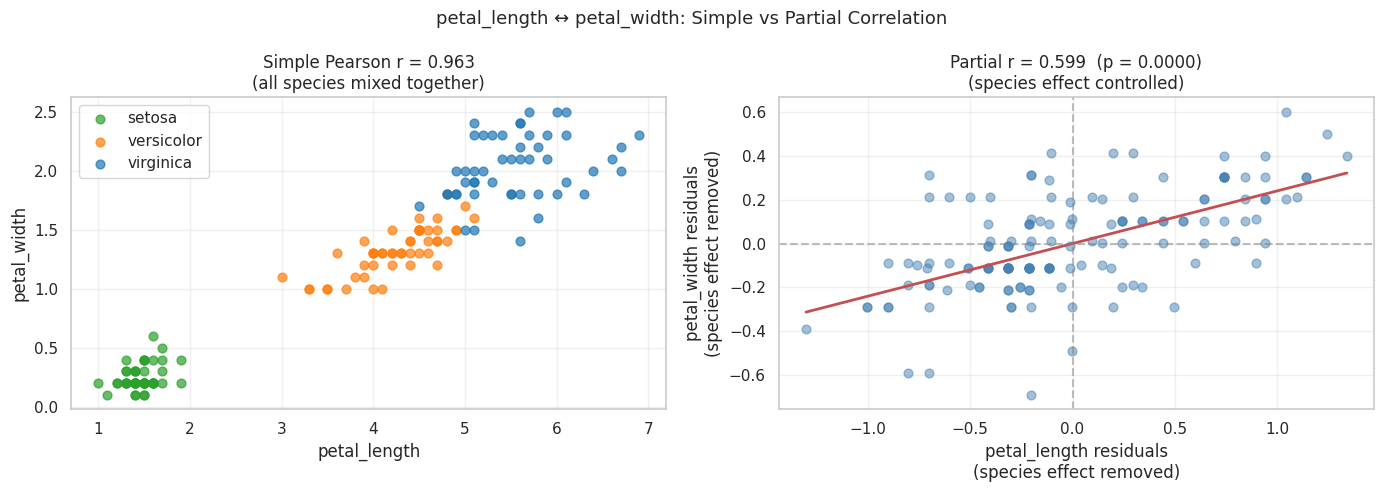

Simple correlation:  r = 0.963
Partial correlation: r = 0.599

Interpretation:
  Even AFTER removing the species effect, petal_length and petal_width
  still have r = 0.599 — so the relationship is real within each species,
  not just an artifact of species size differences.


In [15]:
# ── Visualize partial correlation for petal_length vs petal_width ─────────────
r_simple, _ = pearsonr(df['petal_length'], df['petal_width'])
r_partial, p_partial, res1, res2 = partial_correlation(
    df, 'petal_length', 'petal_width', 'species_code')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: simple correlation
colors = {'setosa': '#2ca02c', 'versicolor': '#ff7f0e', 'virginica': '#1f77b4'}
for sp, grp in df.groupby('species'):
    axes[0].scatter(grp['petal_length'], grp['petal_width'],
                    label=sp, alpha=0.7, s=40, color=colors[sp])
axes[0].set_xlabel('petal_length'); axes[0].set_ylabel('petal_width')
axes[0].set_title(f'Simple Pearson r = {r_simple:.3f}\n(all species mixed together)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right: partial correlation (residuals)
axes[1].scatter(res1, res2, alpha=0.5, s=40, color='steelblue')
m, b, *_ = stats.linregress(res1, res2)
xl = np.linspace(res1.min(), res1.max(), 100)
axes[1].plot(xl, m*xl + b, 'r-', lw=2)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('petal_length residuals\n(species effect removed)')
axes[1].set_ylabel('petal_width residuals\n(species effect removed)')
axes[1].set_title(f'Partial r = {r_partial:.3f}  (p = {p_partial:.4f})\n(species effect controlled)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('petal_length ↔ petal_width: Simple vs Partial Correlation', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Simple correlation:  r = {r_simple:.3f}")
print(f"Partial correlation: r = {r_partial:.3f}")
print()
print("Interpretation:")
print(f"  Even AFTER removing the species effect, petal_length and petal_width")
print(f"  still have r = {r_partial:.3f} — so the relationship is real within each species,")
print(f"  not just an artifact of species size differences.")

---
## Section 8 — Confidence Intervals (Fisher's Z Transformation)

A single correlation number like r = 0.87 is just a **point estimate** — our best guess from this sample. But what if we collected a different sample of 150 flowers? We'd get a slightly different r.

A **confidence interval (CI)** gives us a range that the true population correlation likely falls in.

**Why not just use the normal distribution directly?**  
Because the sampling distribution of r is skewed (not symmetric), especially when r is close to +1 or -1. Fisher's Z transformation converts r to a value `z` that IS normally distributed, letting us build symmetric confidence intervals.

**Steps:**
1. Transform: $z = 0.5 \ln\left(\frac{1+r}{1-r}\right)$ (Fisher's Z)
2. Standard error: $SE_z = \frac{1}{\sqrt{n-3}}$
3. Build CI in z-space, then transform back to r-space

In [16]:
# ── Fisher's Z confidence intervals ──────────────────────────────────────────

def fishers_z(r):
    """Convert Pearson r to Fisher's Z (makes the distribution normal)."""
    # Clip r slightly away from ±1 to avoid log(0)
    r = np.clip(r, -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

def inverse_fishers_z(z):
    """Convert Fisher's Z back to Pearson r."""
    return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

def correlation_ci(r, n, confidence=0.95):
    """
    Compute confidence interval for Pearson r using Fisher's Z.
    Returns (r_lower, r_upper).
    """
    z = fishers_z(r)
    se = 1 / np.sqrt(n - 3)       # Standard error in z-space
    alpha = 1 - confidence
    z_crit = stats.norm.ppf(1 - alpha / 2)  # e.g., 1.96 for 95%

    z_lower = z - z_crit * se
    z_upper = z + z_crit * se

    return inverse_fishers_z(z_lower), inverse_fishers_z(z_upper)


# ── Print CI for all pairs ────────────────────────────────────────────────────
print("=" * 70)
print("95% CONFIDENCE INTERVALS FOR PEARSON r (Fisher's Z Method)")
print("=" * 70)
print("  A 95% CI means: if we repeated the study many times, 95% of the")
print("  computed intervals would contain the true population correlation.\n")

ci_results = []
for v1, v2 in combinations(numeric_vars, 2):
    r, p = pearsonr(df[v1], df[v2])
    lo, hi = correlation_ci(r, len(df))
    ci_results.append((v1, v2, r, lo, hi))
    print(f"  {v1} ↔ {v2}")
    print(f"    r = {r:+.3f}   95% CI: [{lo:+.3f}, {hi:+.3f}]")
    print()

95% CONFIDENCE INTERVALS FOR PEARSON r (Fisher's Z Method)
  A 95% CI means: if we repeated the study many times, 95% of the
  computed intervals would contain the true population correlation.

  sepal_length ↔ sepal_width
    r = -0.118   95% CI: [-0.273, +0.044]

  sepal_length ↔ petal_length
    r = +0.872   95% CI: [+0.827, +0.906]

  sepal_length ↔ petal_width
    r = +0.818   95% CI: [+0.757, +0.865]

  sepal_width ↔ petal_length
    r = -0.428   95% CI: [-0.551, -0.288]

  sepal_width ↔ petal_width
    r = -0.366   95% CI: [-0.497, -0.219]

  petal_length ↔ petal_width
    r = +0.963   95% CI: [+0.949, +0.973]



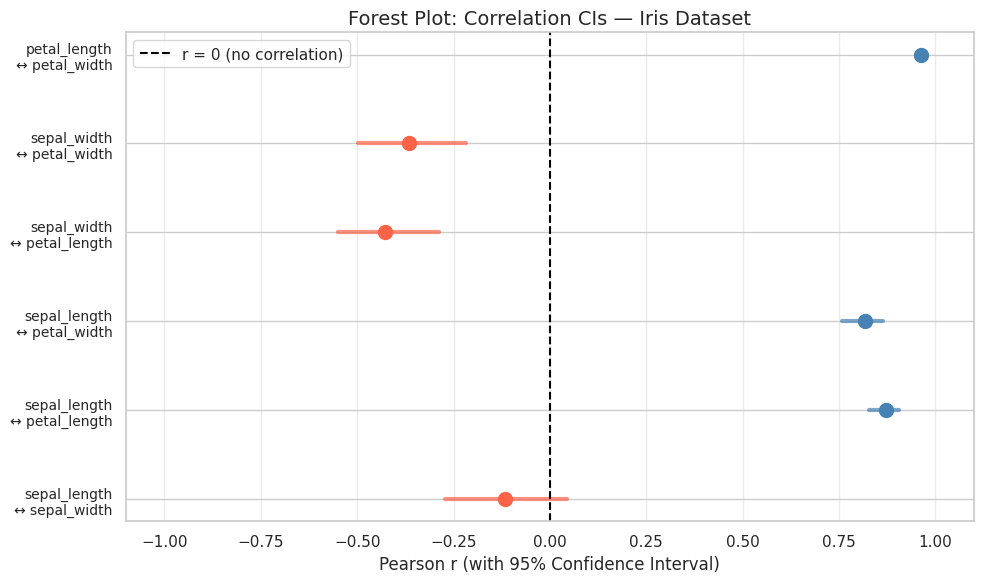

Reading the plot:
  • Each horizontal bar = 95% CI for that correlation
  • Dot = the observed r
  • If bar does NOT cross the dashed line (r=0) → significant correlation
  • Narrow bar = more certainty,  Wide bar = more uncertainty


In [17]:
# ── Forest plot of all confidence intervals ───────────────────────────────────
# A forest plot shows the correlation (dot) and its CI (horizontal bar).
# If the CI does not cross zero, the correlation is statistically significant.

fig, ax = plt.subplots(figsize=(10, 6))

labels = [f"{v1}\n↔ {v2}" for v1, v2, *_ in ci_results]
rs = [r for _, _, r, _, _ in ci_results]
lows = [lo for _, _, _, lo, _ in ci_results]
highs = [hi for _, _, _, _, hi in ci_results]

y_pos = np.arange(len(labels))
colors_ci = ['steelblue' if r > 0 else 'tomato' for r in rs]

for i, (r, lo, hi, color) in enumerate(zip(rs, lows, highs, colors_ci)):
    ax.plot([lo, hi], [i, i], color=color, linewidth=3, alpha=0.7)
    ax.plot(r, i, 'o', color=color, markersize=10, zorder=5)

ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label='r = 0 (no correlation)')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Pearson r (with 95% Confidence Interval)', fontsize=12)
ax.set_title('Forest Plot: Correlation CIs — Iris Dataset', fontsize=14)
ax.set_xlim(-1.1, 1.1)
ax.legend()
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print("Reading the plot:")
print("  • Each horizontal bar = 95% CI for that correlation")
print("  • Dot = the observed r")
print("  • If bar does NOT cross the dashed line (r=0) → significant correlation")
print("  • Narrow bar = more certainty,  Wide bar = more uncertainty")

petal_length ↔ petal_width
  Observed r         = 0.9629
  Fisher's Z 95% CI  = [0.9491, 0.9730]
  Bootstrap   95% CI = [0.9520, 0.9722]
  Both methods agree closely — the correlation is very reliable.


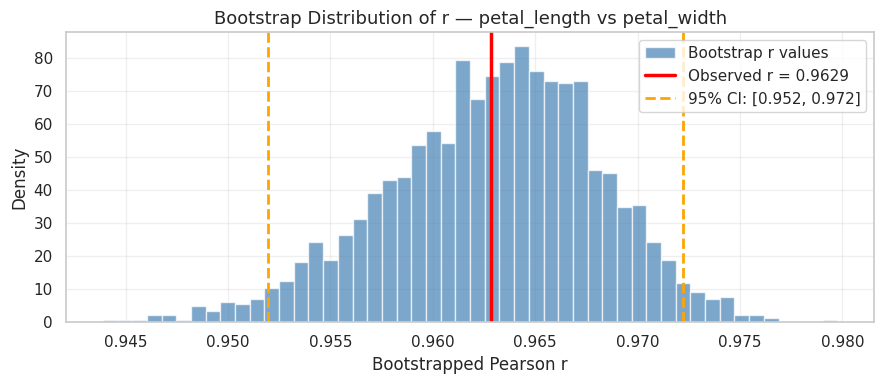

In [18]:
# ── Bootstrap confidence intervals (alternative approach) ─────────────────────
# Another way to get a CI: resample the data many times and see
# how much the correlation varies. This makes NO assumptions about normality.

def bootstrap_ci(x, y, n_bootstrap=2000, confidence=0.95, seed=42):
    """
    Bootstrap confidence interval for Pearson r.
    Resamples the data 2000 times and computes r each time.
    The CI is the 2.5th and 97.5th percentiles of those 2000 values.
    """
    rng = np.random.default_rng(seed)
    boot_rs = []
    n = len(x)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)  # Resample with replacement
        r_boot, _ = pearsonr(x[idx], y[idx])
        boot_rs.append(r_boot)
    alpha = (1 - confidence) / 2
    lo = np.percentile(boot_rs, alpha * 100)
    hi = np.percentile(boot_rs, (1 - alpha) * 100)
    return lo, hi, np.array(boot_rs)


# Apply to petal_length vs petal_width
x = df['petal_length'].values
y = df['petal_width'].values
r_obs, _ = pearsonr(x, y)
fisher_lo, fisher_hi = correlation_ci(r_obs, len(df))
boot_lo, boot_hi, boot_dist = bootstrap_ci(x, y)

print(f"petal_length ↔ petal_width")
print(f"  Observed r         = {r_obs:.4f}")
print(f"  Fisher's Z 95% CI  = [{fisher_lo:.4f}, {fisher_hi:.4f}]")
print(f"  Bootstrap   95% CI = [{boot_lo:.4f}, {boot_hi:.4f}]")
print(f"  Both methods agree closely — the correlation is very reliable.")

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_dist, bins=50, density=True, alpha=0.7, color='steelblue',
        edgecolor='white', label='Bootstrap r values')
ax.axvline(r_obs, color='red', lw=2.5, label=f'Observed r = {r_obs:.4f}')
ax.axvline(boot_lo, color='orange', lw=2, linestyle='--',
           label=f'95% CI: [{boot_lo:.3f}, {boot_hi:.3f}]')
ax.axvline(boot_hi, color='orange', lw=2, linestyle='--')
ax.set_xlabel('Bootstrapped Pearson r', fontsize=12)
ax.set_ylabel('Density')
ax.set_title('Bootstrap Distribution of r — petal_length vs petal_width', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 9 — Summary & Key Takeaways

Let's pull everything together.

In [19]:
# ── Final summary table ───────────────────────────────────────────────────────
print("=" * 70)
print("FINAL SUMMARY — Iris Correlation Analysis")
print("=" * 70)

print("\n  Variable Pair                        | Pearson r | Spearman ρ | 95% CI")
print("  " + "-"*67)

for v1, v2 in combinations(numeric_vars, 2):
    r_p, _ = pearsonr(df[v1], df[v2])
    r_s, _ = spearmanr(df[v1], df[v2])
    lo, hi = correlation_ci(r_p, len(df))
    pair_label = f"{v1[:10]} ↔ {v2[:10]}"
    print(f"  {pair_label:<36} | {r_p:+.3f}     | {r_s:+.3f}      | [{lo:+.3f}, {hi:+.3f}]")

print("\n")
print("Key findings:")
print("  1. petal_length ↔ petal_width: r ≈ 0.96 — extremely strong positive.")
print("     Longer petals are almost always wider too.")
print()
print("  2. sepal_length ↔ petal_length: r ≈ 0.87 — strong positive.")
print("     Flowers with longer sepals tend to have longer petals.")
print()
print("  3. sepal_width ↔ petal_width: r ≈ −0.37 — weak negative.")
print("     Flowers with wider sepals tend to have slightly narrower petals.")
print()
print("  4. Partial correlation (controlling for species) reduces petal r")
print("     slightly — species is a confounder, but the within-species")
print("     relationship is still strong and real.")
print()
print("  5. Pearson and Spearman agree closely throughout, meaning the")
print("     relationships are essentially linear and outliers aren't a problem.")

FINAL SUMMARY — Iris Correlation Analysis

  Variable Pair                        | Pearson r | Spearman ρ | 95% CI
  -------------------------------------------------------------------
  sepal_leng ↔ sepal_widt              | -0.118     | -0.167      | [-0.273, +0.044]
  sepal_leng ↔ petal_leng              | +0.872     | +0.882      | [+0.827, +0.906]
  sepal_leng ↔ petal_widt              | +0.818     | +0.834      | [+0.757, +0.865]
  sepal_widt ↔ petal_leng              | -0.428     | -0.310      | [-0.551, -0.288]
  sepal_widt ↔ petal_widt              | -0.366     | -0.289      | [-0.497, -0.219]
  petal_leng ↔ petal_widt              | +0.963     | +0.938      | [+0.949, +0.973]


Key findings:
  1. petal_length ↔ petal_width: r ≈ 0.96 — extremely strong positive.
     Longer petals are almost always wider too.

  2. sepal_length ↔ petal_length: r ≈ 0.87 — strong positive.
     Flowers with longer sepals tend to have longer petals.

  3. sepal_width ↔ petal_width: r ≈ −0.37 — w

In [21]:
# ── Final concept cheat-sheet ─────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              CORRELATION ANALYSIS — QUICK REFERENCE                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  METHOD        WHEN TO USE                                           ║
║  ──────────    ───────────────────────────────────                   ║
║  Pearson r     Normal data, linear relationship, no outliers         ║
║  Spearman ρ    Non-normal, outliers, or monotonic (not linear)       ║
║  Partial r     When a 3rd variable might be confounding the result   ║
║  Fisher CI     When you need a confidence interval for r             ║
║  Bootstrap CI  When you want CI with no distribution assumptions     ║
║                                                                      ║
║  STRENGTH      RANGE                                                 ║
║  ──────────    ──────────────────                                    ║
║  Strong        |r| ≥ 0.7                                             ║
║  Moderate      0.3 ≤ |r| < 0.7                                       ║
║  Weak          |r| < 0.3                                             ║
║                                                                      ║
║  ⚠  IMPORTANT: Correlation ≠ Causation                              ║
║     Just because two variables are correlated does NOT mean          ║
║     one causes the other. Always think about confounders!            ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║              CORRELATION ANALYSIS — QUICK REFERENCE                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  METHOD        WHEN TO USE                                           ║
║  ──────────    ───────────────────────────────────                   ║
║  Pearson r     Normal data, linear relationship, no outliers         ║
║  Spearman ρ    Non-normal, outliers, or monotonic (not linear)       ║
║  Partial r     When a 3rd variable might be confounding the result   ║
║  Fisher CI     When you need a confidence interval for r             ║
║  Bootstrap CI  When you want CI with no distribution assumptions     ║
║                                                                      ║
║  STRENGTH      RANGE                                                 ║
║  ──────────    ──────────────────               